In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df=pd.read_csv('/content/Telecom_customer_churn.csv')
print(df.info())
print(df.describe())
print(df.head(5))
print(df.shape)
print(df.isnull().sum())
print(df.columns.tolist())
print(df['Churn'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
print(df['TotalCharges'].unique()[:20])

['29.85' '1889.5' '108.15' '1840.75' '151.65' '820.5' '1949.4' '301.9'
 '3046.05' '3487.95' '587.45' '326.8' '5681.1' '5036.3' '2686.05'
 '7895.15' '1022.95' '7382.25' '528.35' '1862.9']


In [ ]:
# Check for any spaces or empty strings
print("Spaces found:")
print((df['TotalCharges'] == ' ').sum())

print("\nEmpty strings found:")
print((df['TotalCharges'] == '').sum())

print("\nSample values:")
print(df['TotalCharges'].head(20).tolist())

Spaces found:
11

Empty strings found:
0

Sample values:
['29.85', '1889.5', '108.15', '1840.75', '151.65', '820.5', '1949.4', '301.9', '3046.05', '3487.95', '587.45', '326.8', '5681.1', '5036.3', '2686.05', '7895.15', '1022.95', '7382.25', '528.35', '1862.9']


In [ ]:
df['TotalCharges']=df['TotalCharges'].replace(' ',np.nan)
df['TotalCharges']=pd.to_numeric(df['TotalCharges'])
df['TotalCharges']=df['TotalCharges'].fillna(df['TotalCharges'].mean())
print(df['TotalCharges'].dtype)
print(df['TotalCharges'].isnull().sum())
print(df['TotalCharges'].head(5))

float64
0
0      29.85
1    1889.50
2     108.15
3    1840.75
4     151.65
Name: TotalCharges, dtype: float64


In [ ]:
df=df.drop('customerID',axis=1)


In [ ]:
df['Churn']=df['Churn'].map({'Yes':1,'No':0})
print(df['Churn'].value_counts())
print(df.shape)

Churn
0    5174
1    1869
Name: count, dtype: int64
(7043, 20)


In [ ]:
print(df.columns.tolist())

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [ ]:
print(df.select_dtypes(include=['int64','float64']).columns.tolist())

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [ ]:
print(df.select_dtypes(include='object').columns.tolist())

['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [ ]:
x=df.drop('Churn',axis=1)
y=df['Churn']
numeric_cols=['tenure','MonthlyCharges','TotalCharges']
binary_cols=['SeniorCitizen']
categorical_cols=['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
                  'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
                  'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
print("x shape : ",x.shape)
print("y shape : ",y.shape)
print("numeric_cols shape : ",numeric_cols)
print("binary_cols shape : ",binary_cols)
print("categorical_cols shape : ",len(categorical_cols),'columns')


x shape :  (7043, 19)
y shape :  (7043,)
numeric_cols shape :  ['tenure', 'MonthlyCharges', 'TotalCharges']
binary_cols shape :  ['SeniorCitizen']
categorical_cols shape :  15 columns


In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42,stratify=y)
print("x_train shape : ",x_train.shape)
print("x_test shape : ",x_test.shape)
print("y_train target rate : ",y_train.mean().round(2))
print("y_test target rate : ",y_test.mean().round(2))

x_train shape :  (5634, 19)
x_test shape :  (1409, 19)
y_train target rate :  0.27
y_test target rate :  0.27


In [ ]:
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
num_pipeline=Pipeline([('scaler',StandardScaler())])
cat_pipeline=Pipeline([('imputer',SimpleImputer(strategy='most_frequent')),
 ('encode',OneHotEncoder(handle_unknown='ignore',sparse_output=False))])
preprocessor=ColumnTransformer([('num',num_pipeline,numeric_cols),('cat',cat_pipeline,categorical_cols),
                        ('bin','passthrough',binary_cols)])

In [ ]:
pip install imbalanced-learn

In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as IMBpipeline

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier


In [ ]:
models={
    'logistic regression':LogisticRegression(random_state=42,max_iter=1000),
    'random forest':RandomForestClassifier(random_state=42,n_estimators=100,n_jobs=-1),
    'svm':SVC(random_state=42,probability=True),
    'knn':KNeighborsClassifier(n_neighbors=5),
    'xgboost':XGBClassifier(verbosity=0,eval_metric='logloss',random_state=42,)
}


In [ ]:
from sklearn.model_selection import StratifiedKFold,cross_val_score
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

In [ ]:
from sklearn.metrics import roc_auc_score
result={}
for name,model in models.items():
  full_pipeline=IMBpipeline([('preprocessor',preprocessor),('smote',SMOTE(random_state=42)),('model',model)])
  recall_score=cross_val_score(full_pipeline,x_train,y_train,cv=cv,scoring='recall')
  f1_score=cross_val_score(full_pipeline,x_train,y_train,cv=cv,scoring='f1')
  roc_auc_score=cross_val_score(full_pipeline,x_train,y_train,cv=cv,scoring='roc_auc')
  print(f"{name} : done")
  print("recall score :",recall_score.mean().round(2))
  print("f1 score :",f1_score.mean().round(2))
  print("roc-auc score :",roc_auc_score.mean().round(2))

logistic regression : done
recall score : 0.79
f1 score : 0.63
roc-auc score : 0.84
random forest : done
recall score : 0.57
f1 score : 0.58
roc-auc score : 0.82
svm : done
recall score : 0.72
f1 score : 0.62
roc-auc score : 0.83
knn : done
recall score : 0.74
f1 score : 0.56
roc-auc score : 0.76
xgboost : done
recall score : 0.57
f1 score : 0.59
roc-auc score : 0.82


In [ ]:
from sklearn.model_selection import GridSearchCV
lr_pipeline=IMBpipeline([('preprocessor',preprocessor),('SMOTE',SMOTE(random_state=42)),
 ('model',LogisticRegression(random_state=42,max_iter=1000))])
param_grid={
    'model__C':[0.01,0.1,1.0,10.0],
    'model__penalty':['l1','l2'],
    'model__solver':['liblinear']
}
grid_search=GridSearchCV(lr_pipeline,param_grid,cv=3,scoring='recall',n_jobs=-1,verbose=1)
grid_search.fit(x_train,y_train)
print(grid_search.best_params_)
print(grid_search.best_score_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
{'model__C': 1.0, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
0.7933202415540586


accuracy score:  0.7374024130589071
recall score:  0.7914438502673797
f1 score:  0.6153846153846154
classificatuon report               precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

roc auc score 0.8405590431165878


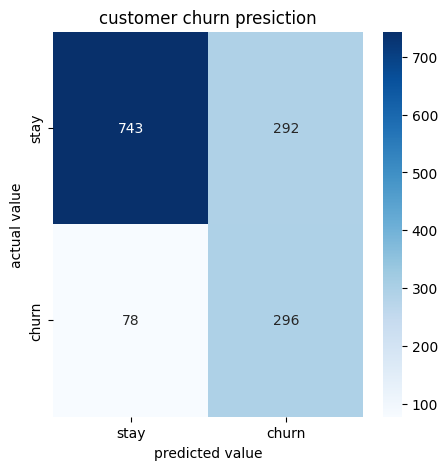

In [ ]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,recall_score,f1_score,roc_auc_score
best_model=grid_search.best_estimator_
y_pred=best_model.predict(x_test)
y_pred_proba=best_model.predict_proba(x_test)[:,1]
print('accuracy score: ',accuracy_score(y_test,y_pred))
print('recall score: ',recall_score(y_test,y_pred))
print('f1 score: ',f1_score(y_test,y_pred))
print('classificatuon report',classification_report(y_test,y_pred))
print('roc auc score',roc_auc_score(y_test,y_pred_proba))
cm=confusion_matrix(y_test,y_pred)
plt.figure(figsize=(5,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=['stay','churn'],yticklabels=['stay','churn'])
plt.title('customer churn presiction')
plt.xlabel('predicted value')
plt.ylabel('actual value')
plt.show()